In [1]:
from matplotlib import pyplot as plt
%matplotlib inline 

In [2]:
#Normal decision tree
from sklearn.datasets import load_wine
wine=load_wine()
input_data=wine.data
target_data=wine.target
#select independent and dependent feature
type(input_data)
X=wine.data
y=target_data

In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [4]:
from sklearn.tree import DecisionTreeClassifier
parameter={"max_depth":6,"splitter":"best","criterion":"gini"}
tree_model= DecisionTreeClassifier(**parameter)
model=tree_model.fit(X_train,y_train)

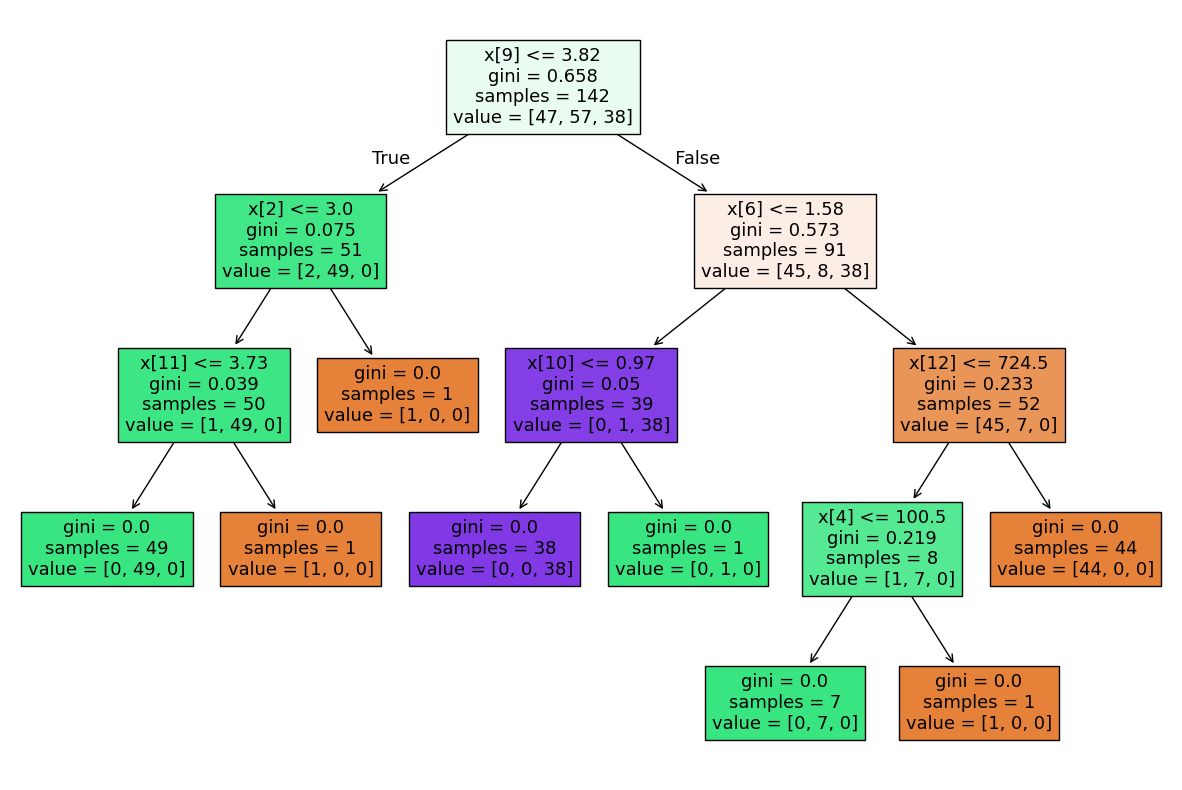

In [5]:
from sklearn import tree
fig=plt.figure(figsize=(15,10))
model=tree.plot_tree(model,filled=True)

In [6]:
y_predict_test=tree_model.predict(X_test)


In [7]:
y_predict_train=tree_model.predict(X_train)

#checking the overfitting or undrfitting by  getting the acccuracy of the trainng and test data set


In [8]:
from sklearn.metrics import accuracy_score,classification_report
test_accuracy= accuracy_score(y_true=y_test,y_pred=y_predict_test)

training_accuracy =  accuracy_score(y_true=y_train,y_pred=y_predict_train)
print(test_accuracy,training_accuracy)

0.9444444444444444 1.0


In [9]:
report=classification_report(y_true=y_test,y_pred=y_predict_test)
print(report)

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        12
           1       0.93      0.93      0.93        14
           2       1.00      1.00      1.00        10

    accuracy                           0.94        36
   macro avg       0.95      0.95      0.95        36
weighted avg       0.94      0.94      0.94        36



In [10]:
#pre pruning 
from sklearn.datasets import load_iris
iris=load_iris()
input_data=iris.data
target_data=iris.target
#select independent and dependent feature
type(input_data)
X=iris.data
y=target_data

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(input_data,target_data,test_size=0.33)

In [12]:
#Making the decision tree for the iris data 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
parameter={
    "splitter":["best","random"],
    "criterion":["gini","entropy"],
    "max_depth":[1,2,3,4,5,6]
}
tree_model=DecisionTreeClassifier()
model=GridSearchCV(tree_model,param_grid=parameter,cv=5,scoring="accuracy")
model=model.fit(X_train,y_train)

/home/vivek/virtual_envs/aiml_venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/home/vivek/virtual_envs/aiml_venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/vivek/virtual_envs/aiml_venv/lib/python3.12/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/home/vivek/virtual_envs/aiml_venv/lib/python3.12/site-packages/sklearn/base.py", line 436, in _validate_params
  

In [13]:
model.best_params_
y_pred=model.predict(X_test)
from sklearn.metrics import accuracy_score,classification_report
accuracy=accuracy_score(y_true=y_test,y_pred=y_pred)
print(accuracy)
print(classification_report(y_true=y_test,y_pred=y_pred))

0.94
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.85      0.92        20
           2       0.88      1.00      0.94        15

    accuracy                           0.94        50
   macro avg       0.94      0.95      0.94        50
weighted avg       0.95      0.94      0.94        50

